<a href="https://colab.research.google.com/github/Sounak-thegeek/SMSSpamClassifier/blob/main/Spam_Ham_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup and Data Loading

In [1]:
# Install the gensim library for Word2Vec.
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.6 MB/s eta 0:00:00


In [2]:
# Import necessary modules from gensim.
import gensim
from gensim.models import Word2Vec, KeyedVectors

In [3]:
# Load the dataset into a pandas DataFrame.
import pandas as pd
messages = pd.read_csv('/content/sample_data/SMSSpamCollection', sep='\t', names=["label", "message"])

In [4]:
# Display the first few rows of the DataFrame to inspect the data.
messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# 2. Text Preprocessing

In [5]:
# Import WordNetLemmatizer for reducing words to their base form.
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [6]:
# Import the regular expression module for text cleaning.
import re

In [7]:
# Download the WordNet corpus for lemmatization.
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [8]:
# Download 'punkt_tab' for tokenization, if needed.
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
# Create a corpus of preprocessed messages.
corpus = []
for i in range(0, len(messages)):
  # Remove non-alphabetic characters and convert to lowercase.
  review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
  review = review.lower()
  # Split into words.
  review = review.split()
  # Lemmatize words to their base form.
  review = [lemmatizer.lemmatize(word) for word in review]
  corpus.append(review)

In [10]:
# Check for any empty reviews in the corpus.
[[i,j,k] for i,j,k in zip(list(map(len,corpus)),corpus, messages['message']) if i<1]

[[0, [], '645'], [0, [], ':) '], [0, [], ':-) :-)']]

In [11]:
# Import necessary NLTK and gensim utilities.
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [12]:
# Assign the preprocessed corpus to a variable named 'words' for clarity.
words = corpus

# 3. Word2Vec Model Training and Vectorization

In [13]:
# Train a Word2Vec model on the preprocessed text corpus.
model = gensim.models.Word2Vec(words)

In [14]:
# Display the vocabulary learned by the Word2Vec model.
model.wv.index_to_key

['i',
 'to',
 'you',
 'a',
 'the',
 'u',
 'and',
 'it',
 'in',
 'is',
 'me',
 'my',
 'for',
 'your',
 'call',
 'of',
 's',
 'that',
 'have',
 'on',
 't',
 'now',
 'are',
 'can',
 'm',
 'so',
 'but',
 'not',
 'or',
 'we',
 'do',
 'get',
 'at',
 'ur',
 'if',
 'will',
 'be',
 'with',
 'no',
 'just',
 'this',
 'gt',
 'lt',
 'go',
 'how',
 'up',
 'when',
 'day',
 'ok',
 'what',
 'free',
 'from',
 'all',
 'out',
 'know',
 'll',
 'come',
 'like',
 'good',
 'time',
 'am',
 'then',
 'got',
 'wa',
 'there',
 'he',
 'love',
 'text',
 'only',
 'want',
 'send',
 'p',
 'r',
 'one',
 'need',
 'txt',
 'today',
 'n',
 'by',
 'going',
 'c',
 'don',
 'stop',
 'she',
 'home',
 'about',
 'lor',
 'sorry',
 'k',
 'see',
 'still',
 'mobile',
 'take',
 'd',
 'back',
 'da',
 'reply',
 'dont',
 'our',
 'think',
 'tell',
 'week',
 'phone',
 'hi',
 'new',
 'they',
 'later',
 'please',
 'any',
 'pls',
 'her',
 'ha',
 'did',
 'co',
 'msg',
 'been',
 'min',
 'an',
 'some',
 'dear',
 'night',
 'make',
 'who',
 'here',

In [15]:
# Show the number of documents (messages) used for training the Word2Vec model.
model.corpus_count

5572

In [16]:
# Display the number of training epochs for the Word2Vec model.
model.epochs

5

In [17]:
# Find words most similar to 'glad' based on learned word embeddings.
model.wv.similar_by_word('glad')

[('lol', 0.9951684474945068),
 ('quite', 0.9949216842651367),
 ('again', 0.9948105812072754),
 ('mind', 0.994675874710083),
 ('kiss', 0.994670033454895),
 ('wanna', 0.9946281909942627),
 ('didnt', 0.9946247935295105),
 ('called', 0.9945873022079468),
 ('v', 0.9945775270462036),
 ('look', 0.9945722222328186)]

In [18]:
# Retrieve the vector representation for the word 'sunny'.
model.wv['sunny']

array([-3.95712368e-02,  5.03740981e-02,  6.19883090e-03,  2.47262213e-02,
        8.71829968e-03, -1.24212220e-01,  3.08603570e-02,  1.76120400e-01,
       -7.76128471e-02, -4.28806208e-02, -3.20319496e-02, -9.86846313e-02,
       -3.56171727e-02,  5.89285418e-02,  7.37142609e-03, -3.51080671e-02,
        4.22404992e-05, -6.98934197e-02, -2.40053963e-02, -1.28432065e-01,
        1.87520199e-02,  1.15167545e-02,  4.95590419e-02, -9.66410153e-03,
       -4.61254967e-03, -3.28826311e-04, -3.40297967e-02, -4.15283479e-02,
       -3.04254219e-02, -4.92583634e-03,  8.69204327e-02, -3.02979555e-02,
        4.64217812e-02, -3.71645018e-02, -2.90575176e-02,  9.90354940e-02,
        1.51355853e-02, -6.19559139e-02, -6.08316623e-02, -1.14610121e-01,
        3.28559577e-02, -7.09063038e-02, -3.08837835e-02,  3.17363627e-02,
        5.40757887e-02, -1.74385943e-02, -3.65156345e-02, -3.10653821e-02,
        2.73538642e-02,  2.25634780e-02,  1.73007343e-02, -6.86593950e-02,
       -2.74118017e-02, -

In [19]:
# Import numpy for numerical operations.
import numpy as np

In [20]:
# Define a function to calculate the average Word2Vec vector for a document.
def avg_word2vec(doc):
  # Filter out words not present in the model's vocabulary.
  word_vectors = [model.wv[word] for word in doc if word in model.wv.index_to_key]
  if len(word_vectors) == 0:
    # Return a zero vector if no words from the document are in the vocabulary.
    return np.zeros(model.vector_size)
  # Compute the mean of word vectors to get a document vector.
  return np.mean(word_vectors, axis=0)

In [21]:
# Install tqdm for displaying progress bars during iterations.
!pip install tqdm

In [22]:
# Import tqdm for progress bar functionality.
from tqdm import tqdm

In [23]:
# Apply the avg_word2vec function to each message in the corpus.
X=[]
for i in tqdm(range(len(words))):
  X.append(avg_word2vec(words[i]))

100%|██████████| 5572/5572 [00:01<00:00, 5420.37it/s]


In [24]:
# Convert the list of document vectors to a NumPy array.
X_new = np.array(X)

In [25]:
# Check the shape of the vectorized data.
X_new.shape

(5572, 100)

# 4. Prepare Data for Model Training

In [26]:
# Convert categorical labels ('ham', 'spam') into numerical (one-hot encoded) format.
y = pd.get_dummies(messages['label'])

In [27]:
# Select the 'ham' column as the target variable (True for ham, False for spam).
y = y.iloc[:, 0].values

In [28]:
# Display the processed target variable.
y

array([ True,  True, False, ...,  True,  True,  True])

In [29]:
# Convert the list of word vectors into a pandas DataFrame.
df_rows = []
for i in range(0, len(X)):
  df_rows.append(pd.DataFrame(X[i].reshape(1, -1)))
df = pd.concat(df_rows, ignore_index=True)

In [30]:
# Check the shape of the DataFrame containing features.
df.shape

(5572, 100)

In [31]:
# Display the first few rows of the feature DataFrame.
df.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.122094,0.228869,0.051379,0.082608,0.000038,-0.496220,0.171945,0.751666,-0.339263,-0.170108,...,0.307831,0.115767,0.098350,0.082736,0.518453,0.284477,0.125052,-0.262973,0.116810,-0.028038
1,-0.125393,0.207267,0.068654,0.079343,-0.020759,-0.453710,0.155236,0.687789,-0.322282,-0.160956,...,0.299389,0.117670,0.083011,0.091152,0.493942,0.292175,0.099350,-0.233506,0.089442,-0.024924
2,-0.113511,0.240502,0.026973,0.092995,0.000919,-0.516597,0.183737,0.810077,-0.360991,-0.171956,...,0.312855,0.126321,0.121696,0.077150,0.514973,0.269497,0.184593,-0.285955,0.137590,-0.000169
3,-0.180628,0.281206,0.080904,0.114460,-0.029885,-0.627402,0.220747,0.981557,-0.444537,-0.220898,...,0.421883,0.164558,0.124897,0.122950,0.694047,0.405175,0.154325,-0.336312,0.132940,-0.026791
4,-0.159311,0.233091,0.079470,0.116816,-0.034864,-0.534314,0.191536,0.822224,-0.371429,-0.186039,...,0.367957,0.135782,0.110067,0.115554,0.608740,0.366417,0.133979,-0.270855,0.088174,-0.027133


In [32]:
# Add the target variable ('Output') to the feature DataFrame.
df['Output'] = y

In [33]:
# Display the DataFrame including the new 'Output' column.
df.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,Output
0,-0.122094,0.228869,0.051379,0.082608,0.000038,-0.496220,0.171945,0.751666,-0.339263,-0.170108,...,0.115767,0.098350,0.082736,0.518453,0.284477,0.125052,-0.262973,0.116810,-0.028038,True
1,-0.125393,0.207267,0.068654,0.079343,-0.020759,-0.453710,0.155236,0.687789,-0.322282,-0.160956,...,0.117670,0.083011,0.091152,0.493942,0.292175,0.099350,-0.233506,0.089442,-0.024924,True
2,-0.113511,0.240502,0.026973,0.092995,0.000919,-0.516597,0.183737,0.810077,-0.360991,-0.171956,...,0.126321,0.121696,0.077150,0.514973,0.269497,0.184593,-0.285955,0.137590,-0.000169,False
3,-0.180628,0.281206,0.080904,0.114460,-0.029885,-0.627402,0.220747,0.981557,-0.444537,-0.220898,...,0.164558,0.124897,0.122950,0.694047,0.405175,0.154325,-0.336312,0.132940,-0.026791,True
4,-0.159311,0.233091,0.079470,0.116816,-0.034864,-0.534314,0.191536,0.822224,-0.371429,-0.186039,...,0.135782,0.110067,0.115554,0.608740,0.366417,0.133979,-0.270855,0.088174,-0.027133,True


In [34]:
# Remove any rows with missing values (if any) from the DataFrame.
df.dropna(inplace=True)

In [35]:
# Verify that there are no remaining null values in the DataFrame.
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
96,0
97,0
98,0
99,0


In [36]:
# Separate features (X) from the target variable.
X = df.iloc[:,:100]

In [37]:
# Assign the 'Output' column as the target variable (y).
y=df['Output']

In [38]:
# Split the data into training and testing sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [39]:
# Display the training features.
X_train

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
1005,-0.147246,0.224989,0.067475,0.097969,-0.006282,-0.518922,0.180687,0.791175,-0.359729,-0.175521,...,0.341811,0.134715,0.100495,0.092242,0.564247,0.326203,0.119292,-0.253538,0.104032,-0.028535
2141,-0.148592,0.255288,0.065086,0.101483,-0.006674,-0.560301,0.198917,0.851768,-0.386029,-0.190545,...,0.355845,0.138770,0.115053,0.091773,0.589053,0.331548,0.146889,-0.274999,0.125663,-0.032523
508,-0.170741,0.260007,0.081715,0.128214,-0.018230,-0.587136,0.211375,0.902928,-0.424155,-0.203367,...,0.390932,0.154526,0.123982,0.117718,0.663098,0.384817,0.148969,-0.279385,0.107767,-0.034618
1569,-0.130005,0.202555,0.045795,0.087115,-0.003758,-0.449023,0.154590,0.696475,-0.320831,-0.161092,...,0.283299,0.117639,0.095095,0.079509,0.488666,0.269167,0.124491,-0.228028,0.107460,-0.023357
4192,-0.138097,0.225841,0.052292,0.090760,0.005865,-0.488109,0.172254,0.749724,-0.345011,-0.172448,...,0.309811,0.124422,0.103105,0.085030,0.532634,0.292393,0.127823,-0.244500,0.112440,-0.034411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,-0.145549,0.218491,0.066015,0.111862,-0.016477,-0.477257,0.170126,0.745363,-0.346311,-0.172958,...,0.314733,0.123384,0.103544,0.098672,0.550952,0.312554,0.129704,-0.236177,0.085370,-0.027357
227,-0.136117,0.255964,0.036327,0.096706,-0.000965,-0.563389,0.192839,0.865741,-0.391197,-0.194729,...,0.336245,0.133156,0.125248,0.083482,0.567412,0.301654,0.169962,-0.300215,0.153308,-0.020921
5342,-0.091450,0.230493,0.007623,0.067681,0.014527,-0.484934,0.171141,0.761243,-0.334889,-0.162115,...,0.282004,0.117473,0.114164,0.061122,0.459354,0.225921,0.169035,-0.289459,0.154206,-0.001357
4045,-0.188130,0.305072,0.068125,0.140696,-0.001288,-0.686911,0.223352,1.032052,-0.478520,-0.238684,...,0.406273,0.167771,0.137988,0.116682,0.732083,0.385174,0.160181,-0.328280,0.157385,-0.037793


In [40]:
# Display the training labels.
y_train

,Output
1005,True
2141,True
508,True
1569,True
4192,True
...,...
108,True
227,False
5342,False
4045,True


# 5. Model Training and Evaluation

In [41]:
# Import the RandomForestClassifier from scikit-learn.
from sklearn.ensemble import RandomForestClassifier

In [42]:
# Instantiate a RandomForestClassifier model.
classifier = RandomForestClassifier()

In [43]:
# Train the RandomForestClassifier model using the training data.
classifier.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
# Make predictions on the test set using the trained model.
y_pred = classifier.predict(X_test)

In [45]:
# Import evaluation metrics from scikit-learn.
from sklearn.metrics import accuracy_score, classification_report

In [46]:
# Calculate and display the accuracy score of the model.
accuracy_score(y_test, y_pred)

0.9739910313901345

In [47]:
# Print the classification report, including precision, recall, and f1-score.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.91      0.88      0.89       138
        True       0.98      0.99      0.99       977

    accuracy                           0.97      1115
   macro avg       0.95      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



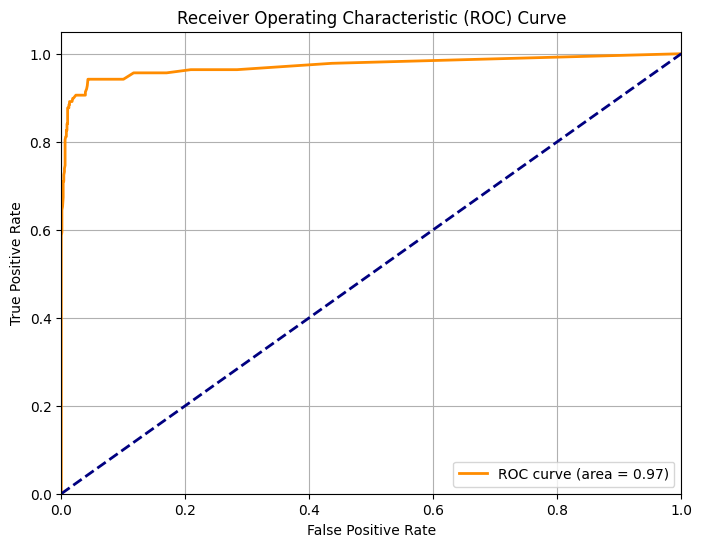

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Convert y_test to numeric (0 or 1) for ROC curve calculation
y_test_numeric = y_test.astype(int)

# Determine the positive class and calculate probabilities for the ROC curve
# This logic handles cases where True/False might be ordered differently by the classifier
if False in classifier.classes_ and True in classifier.classes_:
    # If False is at index 0 and True at index 1
    if list(classifier.classes_)[0] == False:
        # Probability of 'False' (which corresponds to Spam if 'ham' is True)
        y_pred_proba = classifier.predict_proba(X_test)[:, 0]
        # roc_curve expects positive class to be 1, so if False is spam and mapped to 0, invert y_test for roc_curve
        fpr, tpr, thresholds = roc_curve(1 - y_test_numeric, y_pred_proba)
    # If True is at index 0 and False at index 1 (unlikely for default boolean handling)
    elif list(classifier.classes_)[0] == True:
        # Probability of 'False' (Spam)
        y_pred_proba = classifier.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(1 - y_test_numeric, y_pred_proba)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Plot the random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [50]:
#GaussianNB
from sklearn.naive_bayes import GaussianNB
classifier_nb = GaussianNB()
classifier_nb.fit(X_train, y_train)

GaussianNB()

In [51]:
y_pred = classifier_nb.predict(X_test)

In [52]:
y_pred

array([False,  True,  True, ...,  True, False,  True])

In [53]:
print(accuracy_score(y_test, y_pred))

0.9130044843049328


### Logistic Regression

In [54]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Instantiate and train the Logistic Regression model
classifier_lr = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
classifier_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [55]:
# Make predictions on the test set
y_pred_lr = classifier_lr.predict(X_test)

In [56]:
y_pred_lr

array([False,  True,  True, ...,  True,  True,  True])

In [57]:
# Evaluate the Logistic Regression model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9551569506726457

Logistic Regression Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.73      0.80       138
        True       0.96      0.99      0.97       977

    accuracy                           0.96      1115
   macro avg       0.92      0.86      0.89      1115
weighted avg       0.95      0.96      0.95      1115

